# 60 - SNP directos GBLUP en bloques (Notebook friendly)

Version derivada del cuaderno 53 para baseline GBLUP con la misma base metodologica nested CV.

## 1) Configuracion global

In [1]:
from pathlib import Path
import re
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import pearsonr

from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.pipeline import Pipeline

# =========================
# Rutas
# =========================
RAW_PATH = Path("merged_all_mind0.20_g0.10_mac1_nomaf_pruned_raw.raw")
PHENO_PATH = Path("pheno_data/BLUEs_across_env.tsv")
META_PATH = Path("pheno_data/giae121_supplemental_file.xlsx")
META_HEADER_ROW = 2

OUTPUT_DIR = Path("results/snp_blocks_notebook_nested5x3_gblup")
GBLUP_OUT = OUTPUT_DIR / "gblup_results.csv"
ALL_OUT = OUTPUT_DIR / "all_results.csv"
BEST_GLOBAL_OUT = OUTPUT_DIR / "best_global_results.csv"
EXCEL_OUT = OUTPUT_DIR / "gblup_results.xlsx"

# =========================
# Flags de ejecucion
# =========================
RUN_GBLUP = True

# =========================
# Validacion cruzada (Nested CV 5x3)
# =========================
N_SPLITS = 5          # outer folds
N_INNER_SPLITS = 3    # inner folds
RANDOM_STATE = 42
PRINT_EVERY_FOLD = False

# =========================
# Control y logging
# =========================
TOP_N_MISSING = 10
STOP_ON_MODEL_ERROR = False

# =========================
# Traits
# =========================
TRAITS_CANDIDATOS = [
    "lodging",
    "plant_height",
    "blumeria_graminis",
    "heading_date",
    "puccinia_hordei",
    "ramularia_collo_cygni",
    "rhynchosporium",
]

# =========================
# Configuracion canonica GBLUP (baseline unico)
# VanRaden se adopta como formulacion de referencia.
# standardized se considero al inicio, pero se excluye del experimento principal.
# =========================
PARAM_GRIDS = {
    "gblup": {
        "grm": ["vanraden"],
        "fit_intercept": [True],
        "optimize_delta": [True],
        "jitter": [1e-8],
        # Referencia tecnica desactivada para baseline principal:
        # "grm": ["standardized"],
    },
}

# =========================
# Import robusto de GBLUPRegressor
# =========================
try:
    from barley_gblup import GBLUPRegressor
    GBLUP_AVAILABLE = True
except Exception:
    GBLUP_AVAILABLE = False
    candidate_paths = [
        Path("barley_gblup_project"),
        Path("..") / "barley_gblup_project",
        Path("../..") / "barley_gblup_project",
    ]
    for cand in candidate_paths:
        if cand.exists():
            sys.path.insert(0, str(cand.resolve()))
            try:
                from barley_gblup import GBLUPRegressor
                GBLUP_AVAILABLE = True
                break
            except Exception:
                pass

if not GBLUP_AVAILABLE:
    raise ImportError(
        "No se pudo importar GBLUPRegressor. "
        "Asegura que existe barley_gblup_project o instala en editable: pip install -e ./barley_gblup_project"
    )

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"GBLUP_AVAILABLE: {GBLUP_AVAILABLE}")


OUTPUT_DIR: results\snp_blocks_notebook_nested5x3_gblup
GBLUP_AVAILABLE: True


### Nota metodologica breve (baseline GBLUP)

Este cuaderno evalua un unico baseline GBLUP canonico sobre SNPs directos reales:

- `grm`: `vanraden`
- `optimize_delta`: `True`

No se realiza una busqueda amplia de hiperparametros, porque el parametro principal de regularizacion (`delta`) se estima internamente durante el ajuste. Se mantiene el esquema nested CV solo por homogeneidad estructural con el resto del proyecto.


## 2) Instalacion opcional de barley_gblup (manual)

In [2]:
# OPCIONAL. No se ejecuta automaticamente.
# Descomenta solo si necesitas instalar el paquete local barley_gblup.

# %pip install -e ./barley_gblup_project

print("Celda opcional de instalacion. No instala nada si no descomentas.")


Celda opcional de instalacion. No instala nada si no descomentas.


## 3) Carga del .raw y preparacion inicial SNP

In [3]:
if not RAW_PATH.exists():
    raise FileNotFoundError(f"No se encuentra el archivo .raw: {RAW_PATH}")

raw = pd.read_csv(RAW_PATH, sep=r"\s+")

print(f"RAW path: {RAW_PATH}")
print(f"raw shape: {raw.shape}")
print("primeras columnas:", raw.columns[:15].tolist())

META_COLS_BASE = ["FID", "IID", "PAT", "MAT", "SEX", "PHENOTYPE"]
meta_cols_present = [c for c in META_COLS_BASE if c in raw.columns]
print("meta cols detectadas:", meta_cols_present)

if "IID" not in raw.columns:
    raise KeyError("La columna IID no existe en el .raw.")

ids = raw["IID"].astype(str).str.strip().rename("IID")
snp_cols = [c for c in raw.columns if c not in META_COLS_BASE]
X_snp = raw[snp_cols].copy()

print(f"SNP matrix: {X_snp.shape}")
print(f"IID unicos: {ids.nunique()} / {len(ids)}")

if ids.duplicated().any():
    raise ValueError("Hay IID duplicados en el .raw. Resolver antes de modelar.")


RAW path: merged_all_mind0.20_g0.10_mac1_nomaf_pruned_raw.raw
raw shape: (1110, 61145)
primeras columnas: ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENOTYPE', 'chr1H_81414_C_T_C', 'chr1H_131970_G_A_G', 'chr1H_674995_T_C_T', 'chr1H_715339_C_T_C', 'chr1H_725342_C_T_C', 'chr1H_745354_T_C_T', 'chr1H_755359_G_T_G', 'chr1H_765367_G_A_G', 'chr1H_775376_G_A_G']
meta cols detectadas: ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENOTYPE']
SNP matrix: (1110, 61139)
IID unicos: 1110 / 1110


## 4) Auditoria basica de SNPs

In [4]:
n_ind, n_snp = X_snp.shape

missing_total = int(X_snp.isna().sum().sum())
missing_prop_global = missing_total / (n_ind * n_snp)

missing_por_snp = X_snp.isna().mean().sort_values(ascending=False)
missing_por_ind = X_snp.isna().mean(axis=1)

print(f"Dimensiones SNP (n x p): {n_ind} x {n_snp}")
print(f"Missing total: {missing_total}")
print(f"Missing global: {missing_prop_global:.4%}")

print("\nTop SNPs con mas missing:")
display(missing_por_snp.head(TOP_N_MISSING).to_frame("missing_rate"))

print("\nTop individuos con mas missing:")
display(
    pd.DataFrame({"IID": ids.values, "missing_rate": missing_por_ind.values})
    .sort_values("missing_rate", ascending=False)
    .head(TOP_N_MISSING)
)


Dimensiones SNP (n x p): 1110 x 61139
Missing total: 1072129
Missing global: 1.5798%

Top SNPs con mas missing:


,missing_rate
chr1H_4419119_T_C_T,0.1
chr7H_347493323_G_A_G,0.1
chr7H_282428120_G_A_G,0.1
chr4H_534605866_C_T_C,0.1
chr5H_285512264_T_C_T,0.1
chr3H_121454488_C_A_C,0.1
chr4H_137126353_C_G_C,0.1
chr4H_188329277_T_A_T,0.1
chr4H_131703570_G_A_G,0.1
chr4H_549311969_G_A_G,0.1



Top individuos con mas missing:


,IID,missing_rate
971,SAMEA110189115,0.067731
968,SAMEA110189114,0.066717
840,SAMEA110189695,0.062971
1106,SAMEA110189428,0.061205
913,SAMEA110189336,0.061139
908,SAMEA110189616,0.058751
911,SAMEA110189335,0.058719
941,SAMEA110189502,0.058555
1105,SAMEA110189426,0.058032
970,SAMEA110189043,0.057443


## 5) Merge fenotipico y construccion de model_df

In [5]:
if not PHENO_PATH.exists():
    raise FileNotFoundError(f"No se encuentra archivo fenotipico: {PHENO_PATH}")
if not META_PATH.exists():
    raise FileNotFoundError(f"No se encuentra metadata: {META_PATH}")

na_vals = ["", "NA", "NaN", "na", "N/A", "null", "NULL"]
df_pheno = pd.read_csv(PHENO_PATH, sep="\t", na_values=na_vals)
meta = pd.read_excel(META_PATH, header=META_HEADER_ROW)
meta = meta.loc[:, ~meta.columns.astype(str).str.contains(r"^Unnamed", regex=True)].copy()

print(f"df_pheno shape: {df_pheno.shape}")
print(f"meta shape: {meta.shape}")

if "genotypes" not in df_pheno.columns:
    raise KeyError("En fenotipo no existe la columna 'genotypes'.")

# IID en metadata
iid_candidates = ["IID", "BioSamples ID", "BioSample ID", "biosamples id", "sample_id", "Sample_ID"]
rename_map = {}
for c in iid_candidates:
    if c in meta.columns:
        rename_map[c] = "IID"
        break
meta = meta.rename(columns=rename_map)
if "IID" not in meta.columns:
    raise KeyError("No se encontro columna IID en metadata.")


def norm_name(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().upper()
    x = re.sub(r"[^A-Z0-9]+", "", x)
    return x if x else np.nan

meta["IID"] = meta["IID"].astype(str).str.strip()
df_pheno["genotypes"] = df_pheno["genotypes"].astype(str).str.strip()
df_pheno["GENO_NORM"] = df_pheno["genotypes"].apply(norm_name)

candidate_name_cols = ["genotype", "genotype name used for BioSamples", "Genebank name"]
meta_name_cols = [c for c in candidate_name_cols if c in meta.columns]
if not meta_name_cols:
    raise KeyError("No hay columnas utiles para construir puente genotipo -> IID.")

bridge_parts = []
for col in meta_name_cols:
    tmp = meta[["IID", col]].copy().rename(columns={col: "GENO_RAW"})
    bridge_parts.append(tmp)

bridge_df = pd.concat(bridge_parts, ignore_index=True)
bridge_df["GENO_NORM"] = bridge_df["GENO_RAW"].apply(norm_name)
bridge_df = bridge_df.dropna(subset=["IID", "GENO_NORM"]).drop_duplicates(["IID", "GENO_NORM"])

# Mantener SOLO traits fenotipicos
pheno_trait_cols = [t for t in TRAITS_CANDIDATOS if t in df_pheno.columns]
if not pheno_trait_cols:
    raise ValueError("Ningun trait candidato existe en df_pheno.")

for t in pheno_trait_cols:
    df_pheno[t] = pd.to_numeric(df_pheno[t], errors="coerce")

pheno_unique = (
    df_pheno.dropna(subset=["GENO_NORM"])
    .groupby("GENO_NORM", as_index=False)[pheno_trait_cols]
    .mean()
)

iid_pheno = bridge_df[["IID", "GENO_NORM"]].merge(pheno_unique, on="GENO_NORM", how="left")
iid_pheno = iid_pheno.drop_duplicates(subset=["IID"])
iid_pheno = iid_pheno[["IID"] + pheno_trait_cols].copy()

# merge final
snp_df = pd.concat([ids, X_snp], axis=1)
model_df = snp_df.merge(iid_pheno, on="IID", how="left")

feature_cols = snp_cols.copy()
traits_disponibles = [t for t in TRAITS_CANDIDATOS if t in model_df.columns]

print("Columnas puente usadas:", meta_name_cols)
print("Traits disponibles:", traits_disponibles)
print(f"model_df shape: {model_df.shape}")


df_pheno shape: (1197, 12)
meta shape: (1110, 15)
Columnas puente usadas: ['genotype', 'genotype name used for BioSamples', 'Genebank name']
Traits disponibles: ['lodging', 'plant_height', 'blumeria_graminis', 'heading_date', 'puccinia_hordei', 'ramularia_collo_cygni', 'rhynchosporium']
model_df shape: (1110, 61147)


## 6) Checks obligatorios previos

In [6]:
# 6.1 Estructura de columnas
if "feature_cols" not in globals():
    raise NameError("feature_cols no existe.")

if "IID" not in model_df.columns:
    raise KeyError("IID no esta presente en model_df.")

feature_set = set(feature_cols)
snp_set = set(snp_cols)
if feature_set != snp_set:
    raise ValueError("feature_cols no coincide exactamente con las columnas SNP.")

traits_in_features = [t for t in traits_disponibles if t in feature_cols]
if traits_in_features:
    raise ValueError(f"Hay traits dentro de feature_cols: {traits_in_features}")

non_snp_cols = [c for c in model_df.columns if c not in feature_cols]
extra_cols = [c for c in non_snp_cols if c not in ["IID"] + traits_disponibles]

print("[CHECK] Estructura")
print(f"Numero columnas SNP: {len(feature_cols)}")
print(f"Numero columnas no SNP: {len(non_snp_cols)}")
print(f"Columnas extra: {extra_cols}")
if extra_cols:
    raise ValueError("Hay columnas inesperadas en model_df.")

# 6.2 Tipos en SNPs
non_numeric_features = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(model_df[c])]
if non_numeric_features:
    raise TypeError(f"Hay features SNP no numericos. Ejemplo: {non_numeric_features[:10]}")

# 6.3 Missing en X
X_full = model_df[feature_cols]
missing_total_X = int(X_full.isna().sum().sum())
missing_prop_X = missing_total_X / (X_full.shape[0] * X_full.shape[1])
missing_by_snp = X_full.isna().mean().sort_values(ascending=False)
missing_by_ind = X_full.isna().mean(axis=1)

print("\n[CHECK] Missing en X")
print(f"Missing total en X: {missing_total_X}")
print(f"Missing global en X: {missing_prop_X:.4%}")
print("Top SNP missing:")
display(missing_by_snp.head(TOP_N_MISSING).to_frame("missing_rate"))
print("Top individuo missing:")
display(
    pd.DataFrame({"IID": model_df["IID"], "missing_rate": missing_by_ind})
    .sort_values("missing_rate", ascending=False)
    .head(TOP_N_MISSING)
)

print("Confirmacion: el pipeline GBLUP incluye SimpleImputer(strategy='mean').")

# 6.4 Resumen por trait (sin frenar todo el notebook)
trait_checks = []
for trait in traits_disponibles:
    y = pd.to_numeric(model_df[trait], errors="coerce")
    mask = y.notna()
    X_sub = X_full.loc[mask]
    y_sub = y.loc[mask]

    n_valid = int(len(y_sub))
    y_std = float(np.nanstd(y_sub.values)) if n_valid > 0 else np.nan
    enough_for_cv = n_valid >= N_SPLITS
    non_constant = bool(np.isfinite(y_std) and y_std > 0)
    can_run = bool(enough_for_cv and non_constant)

    trait_checks.append({
        "trait": trait,
        "n_valid": n_valid,
        "enough_for_cv": enough_for_cv,
        "non_constant": non_constant,
        "can_run": can_run,
        "y_std": y_std,
    })

trait_checks_df = pd.DataFrame(trait_checks)
print("\n[CHECK] Resumen por trait")
display(trait_checks_df)

traits_no_elegibles = trait_checks_df.loc[~trait_checks_df["can_run"], "trait"].tolist()
if traits_no_elegibles:
    print("\n[AVISO] Traits que se omitiran automaticamente durante el bloque GBLUP:")
    print(traits_no_elegibles)

if not trait_checks_df["can_run"].any():
    raise RuntimeError("Ningun trait tiene muestras suficientes y varianza para ejecutar nested CV.")

print("Checks completados.")


[CHECK] Estructura
Numero columnas SNP: 61139
Numero columnas no SNP: 8
Columnas extra: []

[CHECK] Missing en X
Missing total en X: 1072129
Missing global en X: 1.5798%
Top SNP missing:


,missing_rate
chr1H_4419119_T_C_T,0.1
chr7H_347493323_G_A_G,0.1
chr7H_282428120_G_A_G,0.1
chr4H_534605866_C_T_C,0.1
chr5H_285512264_T_C_T,0.1
chr3H_121454488_C_A_C,0.1
chr4H_137126353_C_G_C,0.1
chr4H_188329277_T_A_T,0.1
chr4H_131703570_G_A_G,0.1
chr4H_549311969_G_A_G,0.1


Top individuo missing:


,IID,missing_rate
971,SAMEA110189115,0.067731
968,SAMEA110189114,0.066717
840,SAMEA110189695,0.062971
1106,SAMEA110189428,0.061205
913,SAMEA110189336,0.061139
908,SAMEA110189616,0.058751
911,SAMEA110189335,0.058719
941,SAMEA110189502,0.058555
1105,SAMEA110189426,0.058032
970,SAMEA110189043,0.057443


Confirmacion: el pipeline GBLUP incluye SimpleImputer(strategy='mean').

[CHECK] Resumen por trait


,trait,n_valid,enough_for_cv,non_constant,can_run,y_std
0,lodging,1110,True,True,True,1.582876
1,plant_height,1110,True,True,True,14.331034
2,blumeria_graminis,1110,True,True,True,1.163945
3,heading_date,1110,True,True,True,31.776664
4,puccinia_hordei,1110,True,True,True,1.188641
5,ramularia_collo_cygni,1110,True,True,True,1.121002
6,rhynchosporium,1110,True,True,True,0.915272


Checks completados.


In [7]:
model_df.sample(5)

,IID,chr1H_81414_C_T_C,chr1H_131970_G_A_G,chr1H_674995_T_C_T,chr1H_715339_C_T_C,chr1H_725342_C_T_C,chr1H_745354_T_C_T,chr1H_755359_G_T_G,chr1H_765367_G_A_G,chr1H_775376_G_A_G,...,chr7H_631979650_A_C_A,chr7H_632100414_G_A_G,chr7H_632170572_C_A_C,lodging,plant_height,blumeria_graminis,heading_date,puccinia_hordei,ramularia_collo_cygni,rhynchosporium
313,SAMEA110189165,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,2.0,...,2.0,2.0,2.0,1.846990,81.774885,3.043797,74.610727,2.291572,4.021619,1.309190
387,SAMEA110189231,0.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,...,2.0,2.0,2.0,5.693121,102.270900,3.888140,78.262968,4.013741,3.709264,1.361338
882,SAMEA6618828,0.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,...,2.0,2.0,2.0,4.298862,100.441597,4.112591,124.658877,7.327437,3.736430,3.231744
455,SAMEA110189005,0.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,...,2.0,2.0,2.0,4.633772,86.987850,3.641455,70.070409,4.922041,4.392169,1.872196
385,SAMEA6618999,0.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,...,2.0,2.0,2.0,4.880556,91.821468,3.842360,68.523896,5.694147,3.816714,1.330384


## 7) Funciones auxiliares comunes

In [8]:
def print_block_header(name):
    print("=" * 80)
    print(f"INICIO BLOQUE: {name.upper()}")
    print("=" * 80)


def print_block_footer(name, elapsed_s, cfg_executed, fits_executed):
    print("=" * 80)
    print(f"FIN BLOQUE: {name.upper()}")
    print(f"Tiempo total del bloque: {elapsed_s:.2f} s")
    print(f"Configuraciones ejecutadas: {cfg_executed}")
    print(f"Fits totales: {fits_executed}")
    print("=" * 80)


def build_pipeline(model_name, params):
    model_name = model_name.lower()

    if model_name == "gblup":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            (
                "model",
                GBLUPRegressor(
                    grm=params["grm"],
                    fit_intercept=params["fit_intercept"],
                    optimize_delta=params["optimize_delta"],
                    jitter=params["jitter"],
                ),
            ),
        ])

    raise ValueError(f"Modelo no soportado: {model_name}")


def prepare_trait_data(model_df, feature_cols, trait):
    y = pd.to_numeric(model_df[trait], errors="coerce")
    mask = y.notna()

    X_trait = model_df.loc[mask, feature_cols]
    y_trait = y.loc[mask].astype(float).values

    if np.isnan(y_trait).any():
        raise ValueError(f"Trait={trait}: y contiene NaN tras limpieza.")
    if X_trait.shape[0] != y_trait.shape[0]:
        raise ValueError(f"Trait={trait}: X e y desalineados.")
    if X_trait.shape[0] < N_SPLITS:
        raise ValueError(f"Trait={trait}: muestras insuficientes para CV.")
    if np.nanstd(y_trait) == 0:
        raise ValueError(f"Trait={trait}: varianza nula en target.")

    return X_trait, y_trait


def nested_oof_predict_manual(model_name, param_grid, X, y, n_outer_splits, n_inner_splits, random_state, print_every_fold=False):
    X_np = X.to_numpy(dtype=float, copy=False)
    y_np = np.asarray(y, dtype=float)

    param_list = list(ParameterGrid(param_grid))
    if not param_list:
        raise ValueError("param_grid sin configuraciones")

    outer_cv = KFold(n_splits=n_outer_splits, shuffle=True, random_state=random_state)

    y_pred = np.full(len(y_np), np.nan, dtype=float)
    best_params_by_fold = []
    fit_count = 0
    t0 = time.perf_counter()

    for fold_idx, (tr_idx, te_idx) in enumerate(outer_cv.split(X_np), start=1):
        X_tr, y_tr = X_np[tr_idx], y_np[tr_idx]
        X_te = X_np[te_idx]

        inner_cv = KFold(n_splits=n_inner_splits, shuffle=True, random_state=random_state + fold_idx)

        best_params = None
        best_score = -np.inf

        for cfg_idx, params in enumerate(param_list, start=1):
            fold_scores = []

            for inner_tr_idx, inner_va_idx in inner_cv.split(X_tr, y_tr):
                est = build_pipeline(model_name, params)
                est.fit(X_tr[inner_tr_idx], y_tr[inner_tr_idx])
                pred_va = est.predict(X_tr[inner_va_idx])
                score = r2_score(y_tr[inner_va_idx], pred_va)
                fold_scores.append(score)
                fit_count += 1

            mean_score = float(np.mean(fold_scores)) if fold_scores else -np.inf
            if mean_score > best_score:
                best_score = mean_score
                best_params = params

            if print_every_fold:
                print(f"    outer_fold={fold_idx}/{n_outer_splits} cfg={cfg_idx}/{len(param_list)} inner_mean_r2={mean_score:.4f}")

        final_est = build_pipeline(model_name, best_params)
        final_est.fit(X_tr, y_tr)
        y_pred[te_idx] = final_est.predict(X_te)
        fit_count += 1

        best_params_by_fold.append(best_params)

    if np.isnan(y_pred).any():
        raise RuntimeError("NaN detectado en predicciones OOF de nested CV.")

    elapsed_s = time.perf_counter() - t0
    return y_pred, fit_count, elapsed_s, best_params_by_fold


def compute_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))

    try:
        pearson_r, pearson_p = pearsonr(y_true, y_pred)
        pearson_r = float(pearson_r)
        pearson_p = float(pearson_p)
    except Exception:
        pearson_r = np.nan
        pearson_p = np.nan

    return {
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }


def params_to_str(params):
    return ", ".join([f"{k}={v}" for k, v in params.items()])


def _mode_params(params_list):
    if not params_list:
        return {}
    keys = sorted(params_list[0].keys())
    serial = [tuple((k, p[k]) for k in keys) for p in params_list]
    counts = pd.Series(serial).value_counts()
    top = dict(counts.index[0])
    return top


def run_model_block(
    model_name,
    model_df,
    feature_cols,
    traits_disponibles,
    param_grid,
    n_outer_splits,
    n_inner_splits,
    random_state,
    print_every_fold=False,
    stop_on_model_error=False,
):
    param_list = list(ParameterGrid(param_grid))
    n_cfg = len(param_list)

    print_block_header(model_name)
    print(f"Configuraciones por trait: {n_cfg}")

    block_results = []
    cfg_executed = 0
    fits_executed = 0
    block_t0 = time.perf_counter()

    fits_por_trait = n_outer_splits * (n_cfg * n_inner_splits + 1)

    for trait in traits_disponibles:
        print("-" * 80)
        print(f"Trait: {trait}")

        try:
            X_trait, y_trait = prepare_trait_data(model_df, feature_cols, trait)

            print(
                f"n={len(y_trait)} | p={X_trait.shape[1]} | configuraciones={n_cfg} | "
                f"fits esperados nested={fits_por_trait}"
            )

            y_pred, fit_count, elapsed_s, best_params_by_fold = nested_oof_predict_manual(
                model_name=model_name,
                param_grid=param_grid,
                X=X_trait,
                y=y_trait,
                n_outer_splits=n_outer_splits,
                n_inner_splits=n_inner_splits,
                random_state=random_state,
                print_every_fold=print_every_fold,
            )

            m = compute_metrics(y_trait, y_pred)
            best_mode = _mode_params(best_params_by_fold)

            block_results.append(
                {
                    "model": model_name,
                    "trait": trait,
                    "params": params_to_str(best_mode),
                    "n_individuos": int(len(y_trait)),
                    "n_snps": int(X_trait.shape[1]),
                    "n_configs_model": int(n_cfg),
                    "fits_por_config": int(n_outer_splits * n_inner_splits),
                    "fits_ejecutados_config": int(fit_count),
                    "pearson_r": m["pearson_r"],
                    "pearson_p": m["pearson_p"],
                    "rmse": m["rmse"],
                    "mae": m["mae"],
                    "r2": m["r2"],
                    "fit_time_s": float(elapsed_s),
                    "cv": f"NestedKFold_manual(outer={n_outer_splits}, inner={n_inner_splits}, random_state={random_state})",
                }
            )

            cfg_executed += n_cfg
            fits_executed += fit_count

            print(
                f"    -> R2={m['r2']:.4f} | Pearson={m['pearson_r']:.4f} | "
                f"RMSE={m['rmse']:.4f} | MAE={m['mae']:.4f} | fits={fit_count} | t={elapsed_s:.2f}s"
            )

        except Exception as exc:
            msg = f"[ERROR] {model_name} | {trait} -> {exc}"
            if stop_on_model_error:
                raise RuntimeError(msg) from exc
            print(msg)

    elapsed_block = time.perf_counter() - block_t0
    block_df = pd.DataFrame(block_results)

    if not block_df.empty:
        block_df = block_df.sort_values(by=["trait", "r2", "pearson_r"], ascending=[True, False, False]).reset_index(drop=True)
        best_by_trait = (
            block_df
            .sort_values(by=["trait", "r2", "pearson_r"], ascending=[True, False, False])
            .groupby("trait", as_index=False)
            .first()
            .sort_values(by=["r2", "pearson_r"], ascending=[False, False])
            .reset_index(drop=True)
        )
    else:
        best_by_trait = pd.DataFrame()

    print_block_footer(model_name, elapsed_block, cfg_executed, fits_executed)

    block_summary = {
        "model": model_name,
        "run": True,
        "time_s": float(elapsed_block),
        "configs_executed": int(cfg_executed),
        "fits_executed": int(fits_executed),
        "configs_per_trait": int(n_cfg),
        "fits_por_trait": int(fits_por_trait),
    }

    return block_df, best_by_trait, block_summary


## 8) Bloque GBLUP (celda independiente)

In [9]:
if RUN_GBLUP:
    resultados_gblup_df, best_gblup_df, summary_gblup = run_model_block(
        model_name="gblup",
        model_df=model_df,
        feature_cols=feature_cols,
        traits_disponibles=traits_disponibles,
        param_grid=PARAM_GRIDS["gblup"],
        n_outer_splits=N_SPLITS,
        n_inner_splits=N_INNER_SPLITS,
        random_state=RANDOM_STATE,
        print_every_fold=PRINT_EVERY_FOLD,
        stop_on_model_error=STOP_ON_MODEL_ERROR,
    )

    if not resultados_gblup_df.empty:
        resultados_gblup_df.to_csv(GBLUP_OUT, index=False)
        print(f"Guardado: {GBLUP_OUT}")
        print("Mejor configuracion por trait (GBLUP):")
        display(best_gblup_df)
    else:
        print("GBLUP: bloque ejecutado sin resultados.")
else:
    resultados_gblup_df = pd.DataFrame()
    best_gblup_df = pd.DataFrame()
    summary_gblup = {
        "model": "gblup",
        "run": False,
        "time_s": 0.0,
        "configs_executed": 0,
        "fits_executed": 0,
        "configs_per_trait": 0,
        "fits_por_trait": 0,
    }
    print("Bloque GBLUP omitido (RUN_GBLUP=False).")


INICIO BLOQUE: GBLUP
Configuraciones por trait: 1
--------------------------------------------------------------------------------
Trait: lodging
n=1110 | p=61139 | configuraciones=1 | fits esperados nested=20
    -> R2=0.7606 | Pearson=0.8724 | RMSE=0.7744 | MAE=0.5872 | fits=20 | t=80.41s
--------------------------------------------------------------------------------
Trait: plant_height
n=1110 | p=61139 | configuraciones=1 | fits esperados nested=20
    -> R2=0.6654 | Pearson=0.8158 | RMSE=8.2896 | MAE=6.1107 | fits=20 | t=75.83s
--------------------------------------------------------------------------------
Trait: blumeria_graminis
n=1110 | p=61139 | configuraciones=1 | fits esperados nested=20
    -> R2=0.5823 | Pearson=0.7632 | RMSE=0.7522 | MAE=0.5869 | fits=20 | t=75.79s
--------------------------------------------------------------------------------
Trait: heading_date
n=1110 | p=61139 | configuraciones=1 | fits esperados nested=20
    -> R2=0.6349 | Pearson=0.7973 | RMSE=19.

,trait,model,params,n_individuos,n_snps,n_configs_model,fits_por_config,fits_ejecutados_config,pearson_r,pearson_p,rmse,mae,r2,fit_time_s,cv
0,lodging,gblup,"fit_intercept=True, grm=vanraden, jitter=1e-08...",1110,61139,1,15,20,0.872372,0.000000e+00,0.774439,0.587213,0.760624,80.406134,"NestedKFold_manual(outer=5, inner=3, random_st..."
1,plant_height,gblup,"fit_intercept=True, grm=vanraden, jitter=1e-08...",1110,61139,1,15,20,0.815771,9.902055e-266,8.289570,6.110733,0.665413,75.825884,"NestedKFold_manual(outer=5, inner=3, random_st..."
2,heading_date,gblup,"fit_intercept=True, grm=vanraden, jitter=1e-08...",1110,61139,1,15,20,0.797251,3.857791e-245,19.199901,12.987290,0.634926,70.764905,"NestedKFold_manual(outer=5, inner=3, random_st..."
3,blumeria_graminis,gblup,"fit_intercept=True, grm=vanraden, jitter=1e-08...",1110,61139,1,15,20,0.763178,2.366859e-212,0.752221,0.586938,0.582337,75.793400,"NestedKFold_manual(outer=5, inner=3, random_st..."
4,puccinia_hordei,gblup,"fit_intercept=True, grm=vanraden, jitter=1e-08...",1110,61139,1,15,20,0.755101,2.207015e-205,0.779544,0.595611,0.569889,82.053452,"NestedKFold_manual(outer=5, inner=3, random_st..."
5,ramularia_collo_cygni,gblup,"fit_intercept=True, grm=vanraden, jitter=1e-08...",1110,61139,1,15,20,0.385151,1.441988e-40,1.035470,0.799403,0.146777,74.728386,"NestedKFold_manual(outer=5, inner=3, random_st..."
6,rhynchosporium,gblup,"fit_intercept=True, grm=vanraden, jitter=1e-08...",1110,61139,1,15,20,0.273948,1.470278e-20,0.883421,0.545396,0.068389,80.140394,"NestedKFold_manual(outer=5, inner=3, random_st..."


## 9) Resumen global final

In [10]:
frames = [df for df in [resultados_gblup_df] if not df.empty]

if not frames:
    raise RuntimeError("No hay resultados en el bloque GBLUP.")

resultados_df = pd.concat(frames, axis=0, ignore_index=True)
resultados_df = resultados_df.sort_values(by=["trait", "r2", "pearson_r"], ascending=[True, False, False]).reset_index(drop=True)

best_global_df = (
    resultados_df
    .sort_values(by=["trait", "r2", "pearson_r"], ascending=[True, False, False])
    .groupby("trait", as_index=False)
    .first()
    .sort_values(by=["r2", "pearson_r"], ascending=[False, False])
    .reset_index(drop=True)
)

resumen_bloques_df = pd.DataFrame([
    summary_gblup,
])

ranking_global_df = (
    resultados_df
    .groupby("model", as_index=False)
    .agg(
        n_runs=("model", "size"),
        mean_r2=("r2", "mean"),
        mean_pearson=("pearson_r", "mean"),
        median_r2=("r2", "median"),
        mean_rmse=("rmse", "mean"),
        mean_mae=("mae", "mean"),
        total_fits=("fits_ejecutados_config", "sum"),
    )
    .sort_values(by=["mean_r2", "mean_pearson"], ascending=[False, False])
    .reset_index(drop=True)
)

total_fits_notebook = int(resumen_bloques_df["fits_executed"].sum())

print("=" * 80)
print("RESUMEN TOTAL FINAL")
print("=" * 80)
print(f"Fits totales del notebook: {total_fits_notebook}")

print("\nMejor configuracion por trait:")
display(best_global_df[["trait", "model", "params", "r2", "pearson_r", "rmse", "mae", "fit_time_s"]])

print("\nTiempo total y numero de fits por algoritmo:")
display(resumen_bloques_df)

print("\nRanking global de modelos:")
display(ranking_global_df)

resultados_df.to_csv(ALL_OUT, index=False)
best_global_df.to_csv(BEST_GLOBAL_OUT, index=False)

with pd.ExcelWriter(EXCEL_OUT) as writer:
    resultados_df.to_excel(writer, sheet_name="all_results", index=False)
    best_global_df.to_excel(writer, sheet_name="best_global", index=False)
    resumen_bloques_df.to_excel(writer, sheet_name="resumen_bloques", index=False)
    ranking_global_df.to_excel(writer, sheet_name="ranking_global", index=False)

print(f"\nGuardado: {ALL_OUT}")
print(f"Guardado: {BEST_GLOBAL_OUT}")
print(f"Guardado: {EXCEL_OUT}")


RESUMEN TOTAL FINAL
Fits totales del notebook: 140

Mejor configuracion por trait:


,trait,model,params,r2,pearson_r,rmse,mae,fit_time_s
0,lodging,gblup,"fit_intercept=True, grm=vanraden, jitter=1e-08...",0.760624,0.872372,0.774439,0.587213,80.406134
1,plant_height,gblup,"fit_intercept=True, grm=vanraden, jitter=1e-08...",0.665413,0.815771,8.289570,6.110733,75.825884
2,heading_date,gblup,"fit_intercept=True, grm=vanraden, jitter=1e-08...",0.634926,0.797251,19.199901,12.987290,70.764905
3,blumeria_graminis,gblup,"fit_intercept=True, grm=vanraden, jitter=1e-08...",0.582337,0.763178,0.752221,0.586938,75.793400
4,puccinia_hordei,gblup,"fit_intercept=True, grm=vanraden, jitter=1e-08...",0.569889,0.755101,0.779544,0.595611,82.053452
5,ramularia_collo_cygni,gblup,"fit_intercept=True, grm=vanraden, jitter=1e-08...",0.146777,0.385151,1.035470,0.799403,74.728386
6,rhynchosporium,gblup,"fit_intercept=True, grm=vanraden, jitter=1e-08...",0.068389,0.273948,0.883421,0.545396,80.140394



Tiempo total y numero de fits por algoritmo:


,model,run,time_s,configs_executed,fits_executed,configs_per_trait,fits_por_trait
0,gblup,True,550.004132,7,140,1,20



Ranking global de modelos:


,model,n_runs,mean_r2,mean_pearson,median_r2,mean_rmse,mean_mae,total_fits
0,gblup,7,0.489765,0.66611,0.582337,4.530652,3.173226,140



Guardado: results\snp_blocks_notebook_nested5x3_gblup\all_results.csv
Guardado: results\snp_blocks_notebook_nested5x3_gblup\best_global_results.csv
Guardado: results\snp_blocks_notebook_nested5x3_gblup\gblup_results.xlsx


## 10) Visualizacion rapida

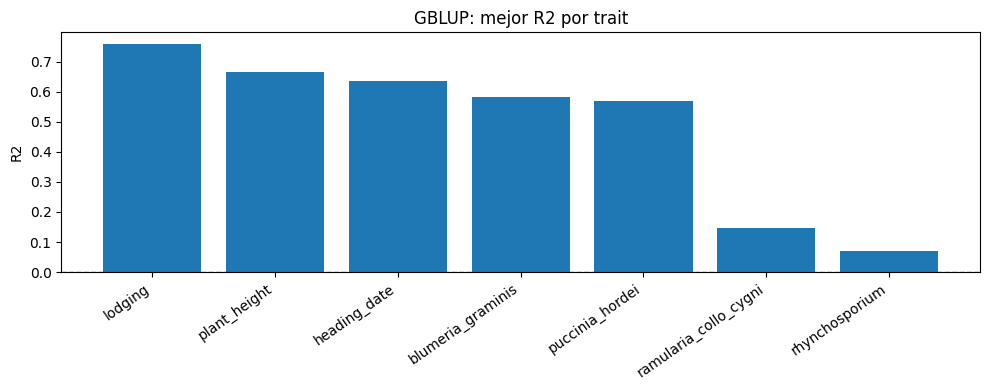

In [11]:
plot_df = best_global_df.sort_values("r2", ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(plot_df["trait"], plot_df["r2"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(rotation=35, ha="right", fontsize=11)
plt.ylabel("R2", fontsize=12)
plt.title("GBLUP: mejor R2 por trait", fontsize=14)
plt.tight_layout()
plt.show()


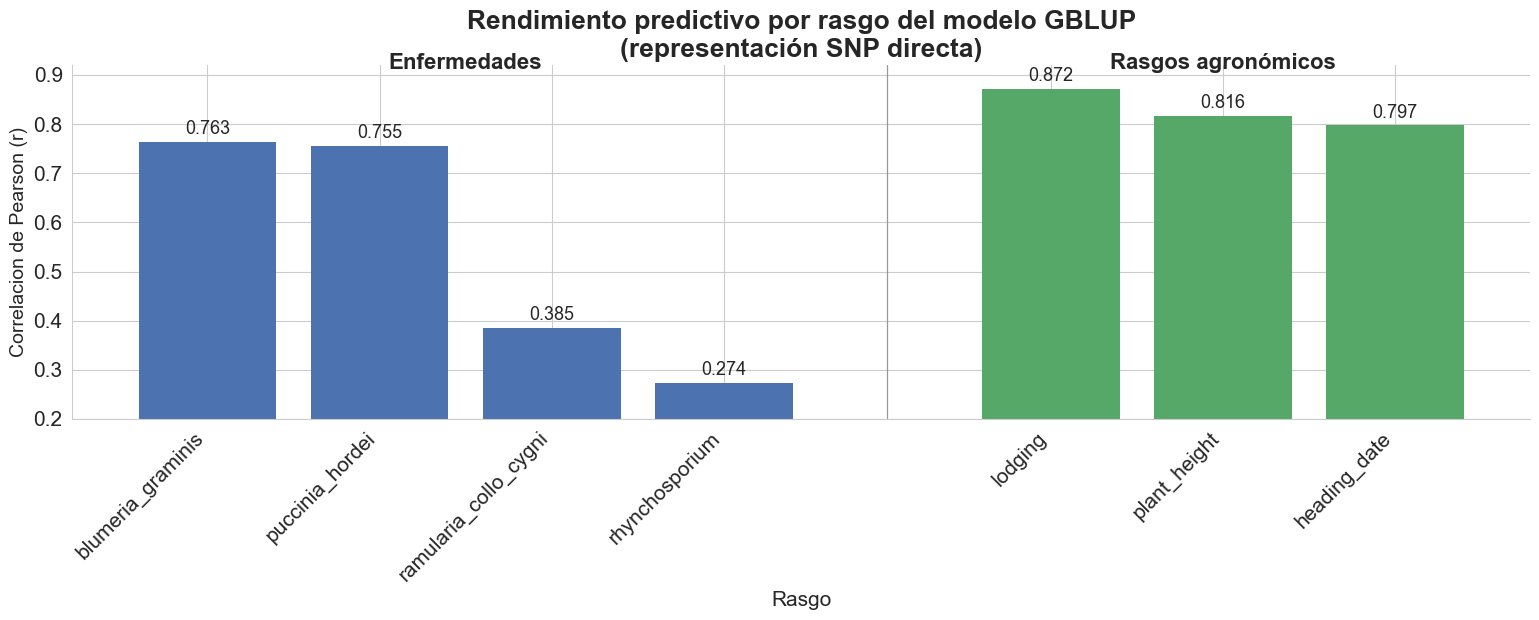

Figura guardada en: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\repo\results\snp_blocks_notebook_nested5x3_gblup\gblup_pearson_r_barplot_academico.png


In [4]:
# =========================================================
# Barplot académico GBLUP (representación SNP directa) por rasgo
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1) Cargar resultados desde CSV (sin recalcular modelos)
# Funciona aunque no hayas ejecutado celdas previas con variables globales.
gblup_out = globals().get("GBLUP_OUT")
all_out = globals().get("ALL_OUT")
output_dir = globals().get("OUTPUT_DIR")

candidates = []
if gblup_out is not None:
    candidates.append(Path(gblup_out))
if all_out is not None:
    candidates.append(Path(all_out))

cwd = Path.cwd().resolve()
for base in [
    cwd,
    cwd / "repo",
    cwd / "nested5x3_unificados",
    cwd.parent,
    cwd.parent / "repo",
    cwd.parent / "nested5x3_unificados",
]:
    candidates.append(base / "results" / "snp_blocks_notebook_nested5x3_gblup" / "gblup_results.csv")
    candidates.append(base / "results" / "snp_blocks_notebook_nested5x3_gblup" / "all_results.csv")

source_csv = next((c for c in candidates if c.exists()), None)
if source_csv is None:
    raise FileNotFoundError("No se encontro CSV de resultados GBLUP en rutas esperadas.")

df_plot = pd.read_csv(source_csv)

# Carpeta de salida robusta
if output_dir is None:
    output_dir = source_csv.parent
else:
    output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

# Si hay columna model, filtrar GBLUP por robustez
if "model" in df_plot.columns:
    df_plot = df_plot[df_plot["model"].astype(str).str.lower() == "gblup"].copy()

# 2) Datos base (sin recalcular nada)
df_plot = df_plot[["trait", "pearson_r"]].dropna().copy()
df_plot = df_plot.groupby("trait", as_index=False)["pearson_r"].mean()

traits_enfermedad = ["blumeria_graminis", "puccinia_hordei", "ramularia_collo_cygni", "rhynchosporium"]
traits_agronomicos = ["heading_date", "lodging", "plant_height"]

enf = df_plot[df_plot["trait"].isin(traits_enfermedad)].sort_values("pearson_r", ascending=False)
agr = df_plot[df_plot["trait"].isin(traits_agronomicos)].sort_values("pearson_r", ascending=False)

plot_data = pd.concat([enf, agr], ignore_index=True)

# 3) Posiciones con separación visual entre bloques
x_enf = np.arange(len(enf))
gap = 0.9
x_agr = np.arange(len(agr)) + len(enf) + gap
x = np.concatenate([x_enf, x_agr])

labels = plot_data["trait"].tolist()
values = plot_data["pearson_r"].to_numpy()

# 4) Colores por bloque
color_enf = "#4c72b0"
color_agr = "#55a868"
bar_colors = [color_enf] * len(enf) + [color_agr] * len(agr)

# 5) Plot
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(15.5, 6.3))
bars = ax.bar(x, values, color=bar_colors, edgecolor="none")

# Etiquetas de valor
for bar, v in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.008,
        f"{v:.3f}",
        ha="center",
        va="bottom",
        fontsize=13
    )

# Separación visual fina
if len(enf) > 0 and len(agr) > 0:
    sep_x = len(enf) - 0.5 + gap / 2
    ax.axvline(sep_x, color="#999999", linewidth=0.9)

# Etiquetas de bloque arriba
ax.set_ylim(0.2, 0.92)
y_top = 0.905
if len(enf) > 0:
    ax.text(x_enf.mean(), y_top, "Enfermedades",
            ha="center", va="bottom", fontsize=16, fontweight="bold")
if len(agr) > 0:
    ax.text(x_agr.mean(), y_top, "Rasgos agronómicos",
            ha="center", va="bottom", fontsize=16, fontweight="bold")

# Título y ejes
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=15)
ax.set_ylabel("Correlacion de Pearson (r)", fontsize=14)
ax.set_xlabel("Rasgo", fontsize=15)
ax.tick_params(axis="y", labelsize=15)
ax.set_title(
    "Rendimiento predictivo por rasgo del modelo GBLUP\n(representación SNP directa)",
    fontsize=19,
    fontweight="bold"
)

sns.despine(ax=ax)
plt.tight_layout()

# Export
out_fig = output_dir / "gblup_pearson_r_barplot_academico.png"
plt.savefig(out_fig, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {out_fig}")